# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv(r"C:\Users\dsh_m\Desktop\Springboard\Frequentist\1585247986_Frequentist_Case_Study\Frequentist Case Study\insurance2.csv")

In [7]:
medical.shape

(1338, 8)

In [10]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [12]:
medical.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'insuranceclaim'],
      dtype='object')

__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

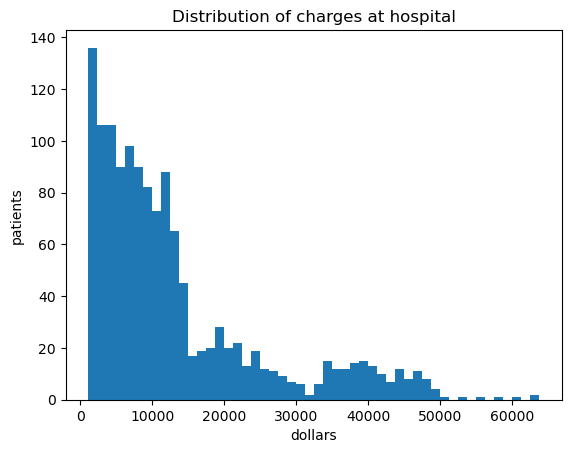

In [16]:
# histogram
_ = plt.hist(medical.charges, bins=50)
_ = plt.xlabel('dollars')
_ = plt.ylabel('patients')
_ = plt.title('Distribution of charges at hospital')

In [18]:
charges_mean = np.mean(medical.charges)
charges_std =  np.std(medical.charges)
print("mean = ", charges_mean, "standard deviation = ", charges_std)

mean =  13270.422265141257 standard deviation =  12105.484975561605


In [20]:
one_std = charges_mean+charges_std
two_std = charges_mean+ (2*charges_std)

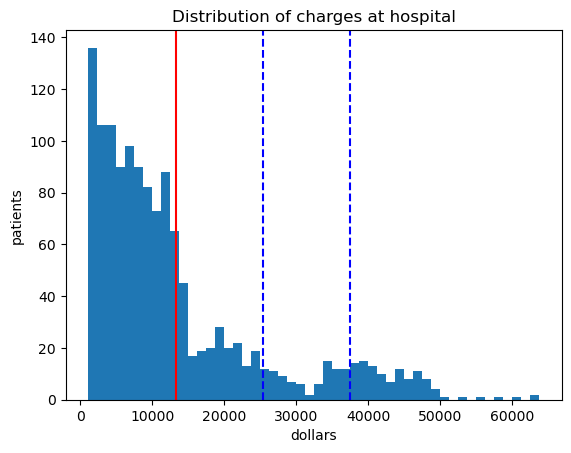

In [22]:
# histogram 2
_ = plt.hist(medical.charges, bins=50)
_ = plt.xlabel('dollars')
_ = plt.ylabel('patients')
_ = plt.title('Distribution of charges at hospital')
_ = plt.axvline(charges_mean, color='r')
_ = plt.axvline(one_std, color='b', linestyle='--')
_ = plt.axvline(two_std, color='b', linestyle='--')

<h1>Appropriateness of Mean and Standard Deviation to the Medical Charges data</h1>
<ul>
<li>When viewing the histogram, the mean and standard deviation numbers make sense.
<li>The majority of individuals have small charges, and a few patients have very large charges.
<li>Interquartile range may also give insight.    
</ul>

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__since it's a sample instead of the full population, Use Bessel's correction for the standard deviation formula - divide by n-1

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ a 1-sided interval is valid with this data

In [29]:
alpha = 1-.095 # 95% confidence level
sample_size = len(medical.charges)
print(sample_size)
degrees_of_freedom = sample_size - 1
t_prob_density = t.pdf(1-alpha,df = degrees_of_freedom) # also known as t_critical, 1-tailed.
margin_of_error = t_prob_density * (charges_std/np.sqrt(sample_size))
lower_bound = charges_mean - margin_of_error
upper_bound = charges_mean + margin_of_error 
print("95% of charges are less than", upper_bound)


1338
95% of charges are less than 13401.830258106851


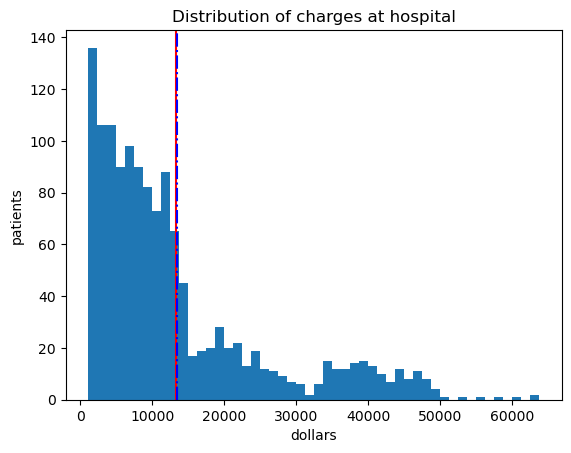

In [31]:
# histogram
_ = plt.hist(medical.charges, bins=50)
_ = plt.xlabel('dollars')
_ = plt.ylabel('patients')
_ = plt.title('Distribution of charges at hospital')
_ = plt.axvline(charges_mean, color='r')
_ = plt.axvline(upper_bound, color='b', linestyle='-.')

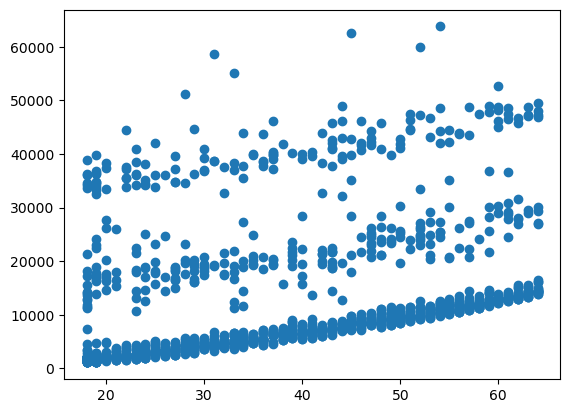

In [33]:
x = medical.age
y= medical.charges
plt.scatter(x,y)

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__
Null hyphothesis - no difference in charges with or without insurance
Alternative hypothesis - there is a difference - those with insurance are charged a different amount

The pooled standard deviation calculates mean and standard deviation by group then weights them to calculate overall variability
. Assumes the variances will have identical variances by default. (https://en.wikipedia.org/wiki/Pooled_variance, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [39]:
# "manual"
ins_mean = medical.groupby(['insuranceclaim'])['charges'].mean()
ins_std = medical.groupby(['insuranceclaim'])['charges'].std()
ins_count = medical.groupby(['insuranceclaim'])['charges'].size()
print("Mean: ",ins_mean)
print("Std: ",ins_std)
print("Count: ",ins_count)

Mean:  insuranceclaim
0     8821.421892
1    16423.928277
Name: charges, dtype: float64
Std:  insuranceclaim
0     6446.510127
1    14045.928419
Name: charges, dtype: float64
Count:  insuranceclaim
0    555
1    783
Name: charges, dtype: int64


In [41]:
mean_ins = 16423.928277
mean_no_ins = 8821.421892
ins_count = 783
no_ins_count = 555
numerator = mean_ins+mean_no_ins
denominator = np.sqrt((1/ins_count)+(1/no_ins_count))
t_manual = numerator / denominator
print(t_manual)

454967.85657488403


In [43]:
ins_numerator = (mean_ins -1)**2
no_ins_numerator = (mean_no_ins - 1)**2
denominator = (ins_count+no_ins_count)-2
pooled_std = np.sqrt((ins_numerator+no_ins_numerator)/denominator)
print(pooled_std)

510.0138071574991


In [59]:
# with scipy
from scipy.stats import ttest_ind



has_ins = medical[medical['insuranceclaim']==1]['charges']
no_ins =  medical[medical['insuranceclaim']==0]['charges']

print(f"The number of patients with insurance: {len(has_ins)}")
print(f"The number of patients without insurance: {len(no_ins)}")

The number of patients with insurance: 783
The number of patients without insurance: 555


In [69]:
# assume equal variances
insurance_t_statistic, insurance_p_value = ttest_ind(has_ins, no_ins, equal_var=True)
print(f"T-statistic: {insurance_t_statistic:.4f}")
print(f"P-value: {insurance_p_value:.4f}")
#print("Equal variances: ",insurance_t)

T-statistic: 11.8933
P-value: 0.0000


In [71]:
# assume unequal variances
ins_t, ins_p = ttest_ind(has_ins, no_ins,equal_var = False)
print(f"T-statistic: {ins_t:.4f}")
print(f"P-value: {ins_p:.4f}")

T-statistic: 13.2980
P-value: 0.0000


In [73]:
# How to interpret
alpha = 0.05 # 95% significance level, standard
if insurance_p_value < alpha:
    print(f"Since p-value ({insurance_p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in medical costs between patients with and without insurance.")
else:
    print(f"Since p-value ({insurance_p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in medical costs between patients with and without insurance.")

# It's always good to look at the means to understand the direction of any difference
print("\nMean Medical Cost for Patients with Insurance:", has_ins.mean())
print("Mean Medical Cost for Patients without Insurance:", no_ins.mean())

Since p-value (0.0000) < alpha (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant difference in medical costs between patients with and without insurance.

Mean Medical Cost for Patients with Insurance: 16423.928276537677
Mean Medical Cost for Patients without Insurance: 8821.421892306305


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__
maybe zmap (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mstats.zmap.html)
? 
Calculate the relative z-scores.

Return an array of z-scores, i.e., scores that are standardized to zero mean and unit variance, where mean and variance are calculated from the comparison array.



## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test